# Calculating the Accuracy of Equations of State

## Peng–Robinson Equation of State (PR‑EOS)

The Peng–Robinson EOS is a cubic equation of state used to model the pressure-volume-temperature (PVT) behavior of pure fluids and mixtures. It is written as:

$$
P = \frac{RT}{V - b} - \frac{a}{\underline{V}(\underline{V} + b) + b(\underline{V} - b)}
$$

Where:

- $P$ = pressure  
- $T$ = temperature  
- $\underline{V}$ = molar volume  
- $R$ = gas constant  
- $a$ = attractive parameter  
- $b$ = co‑volume (repulsive) parameter  


## Pure‑Component Parameters

### Acentric‑factor‑dependent parameter $\kappa$

$$
\kappa(\omega) = 0.37464 + 1.54226\,\omega - 0.26992\,\omega^2
$$

This adjusts the temperature dependence of attractive forces based on molecular shape and polarity.


### Temperature correction factor $\alpha(T_r, \omega)$

$$
\alpha(T_r, \omega) = \left[1 + \kappa(\omega)\left(1 - \sqrt{T_r}\right)\right]^2
$$

Where:

$$
T_r = \frac{T}{T_c}
$$

This term reduces attractive forces as temperature increases.


### Attractive parameter $a$

$$
a = 0.45724 \frac{R^2 T_c^2}{P_c} \, \alpha(T_r, \omega)
$$

Controls long‑range intermolecular attraction.


### Repulsive parameter $b$

$$
b = 0.07780 \frac{RT_c}{P_c}
$$

Represents excluded volume due to finite molecular size.



## Mixing Rules for a Binary Mixture

For a mixture of components 1 and 2 with mole fractions $x_1$ and $x_2$:

### Mixture attractive parameter $a_{\text{mix}}$

$$
a_{\text{mix}} = x_1^2 a_1 + x_2^2 a_2 + 2 x_1 x_2 \sqrt{a_1 a_2} (1 - k_{12})
$$

Where:

- $k_{12}$ = binary interaction parameter  
- For similar nonpolar molecules (hexane/decane), $k_{12} \approx 0$

**What this term does:**  
It blends the attractive forces of the two components and corrects for non‑ideal interactions.


### Mixture repulsive parameter $b_{\text{mix}}$

$$
b_{\text{mix}} = x_1 b_1 + x_2 b_2
$$

This is a simple linear mixing rule because repulsive forces are short‑range and nearly additive.

## 3. Compressibility Factor Equation

The PR EOS can be written as a cubic equation in the compressibility factor $Z$:

$$
Z^3 + \alpha Z^2 + \beta Z + \gamma = 0
$$

Where:

$$
A = \frac{a_{\text{mix}} P}{(RT)^2}, \qquad B = \frac{b_{\text{mix}} P}{RT}
$$

And the coefficients are:

$$
\alpha = -(1 - B)
$$

$$
\beta = A - 3B^2 - 2B
$$

$$
\gamma = -(AB - B^2 - B^3)
$$

**What this does:**  
Solving this cubic gives up to three real roots:

- smallest root → **liquid phase**  
- largest root → **vapor phase**  


## 4. Molar Volume

Once a real root $Z$ is selected:

$$
V = \frac{ZRT}{P}
$$

This gives the molar volume of the mixture.

## 5. Density of the Mixture

If the mixture molecular weight is:

$$
MW = x_1 MW_1 + x_2 MW_2
$$

Then the density is:

$$
\rho = \frac{MW}{V}
$$


## Let's code these equations up

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def kappa(w):
    return 0.37464+1.54266*w-0.26992*w**2
def alpha(Tr,w):    
    return (1+kappa(w)*(1-np.sqrt(Tr)))**2

def a(T,Tc,Pc,w):
    Tr=T/Tc
    return 0.45724*(R*Tc)**2/Pc*alpha(Tr,w)

def b(Tc,Pc):
    return 0.07780*R*Tc/(Pc)

def amix(x1):
    x2 = (1-x1)
    return a1*x1**2+a2*x2**2+x1*x2*np.sqrt(a1*a2)*(1-kij)
    
def bmix(x1):
    x2 = (1-x1)
    return b1*x1 + b2*x2

def Zcoeff(T,P,a,b):
    A=a*P/(R*T)**2
    B=b*P/(R*T)
    
    return [1,
            -1+B,
            A-3*B**2-2*B,
            -A*B+B**2+B**3]

## Let's do an example with Water and Ethanol based on the critical properties given below:

| Compound | Formula | MW (g/mol) | Tc (K) | Pc (MPa) | Acentric Factor (ω) |
|----------|---------|------------|--------|----------|----------------------|
| **Water** | H₂O | 18.015 | 647.1 | 22.06 | 0.344 |
| **Ethanol** | C₂H₆O | 46.068 | 514.0 | 6.14 | 0.645 |



In [14]:
T=298 #K
P=101325 #Pa
##water properties
Tc1=647.13 #K
Pc1=220.55 #bar
w1=0.344861

##ethanol properties
Tc2=514 #Tc
Pc2=63.90 #bar
w2=0.643558

R=8.314##j/mol*k
kij=-0.11

a1 = a(T,Tc1,Pc1*10**5,w1)
a2 = a(T,Tc2,Pc2*10**5,w2)
b1 = b(Tc1,Pc1*10**5)
b2 = b(Tc2,Pc2*10**5)

x1 = np.linspace(0,1)
amix_ = amix(x1)
bmix_ = bmix(x1)
print(a1,a2, amix_)
print(b1*10**6, b2*10**6, bmix_*10**6)

0.9849011292292787 2.206916461704518 [2.20691646 2.15088369 2.09614649 2.04270487 1.99055881 1.93970832
 1.8901534  1.84189405 1.79493027 1.74926207 1.70488943 1.66181236
 1.62003086 1.57954493 1.54035457 1.50245979 1.46586057 1.43055692
 1.39654884 1.36383633 1.33241939 1.30229803 1.27347223 1.245942
 1.21970734 1.19476825 1.17112473 1.14877679 1.12772441 1.1079676
 1.08950636 1.07234069 1.05647059 1.04189606 1.02861711 1.01663372
 1.0059459  0.99655365 0.98845697 0.98165586 0.97615033 0.97194036
 0.96902596 0.96740713 0.96708387 0.96805618 0.97032406 0.97388752
 0.97874654 0.98490113]
18.97903333466334 52.029766635367764 [52.02976664 51.35526187 50.68075711 50.00625235 49.33174759 48.65724283
 47.98273807 47.30823331 46.63372855 45.95922378 45.28471902 44.61021426
 43.9357095  43.26120474 42.58669998 41.91219522 41.23769046 40.56318569
 39.88868093 39.21417617 38.53967141 37.86516665 37.19066189 36.51615713
 35.84165237 35.1671476  34.49264284 33.81813808 33.14363332 32.46912856
 31.

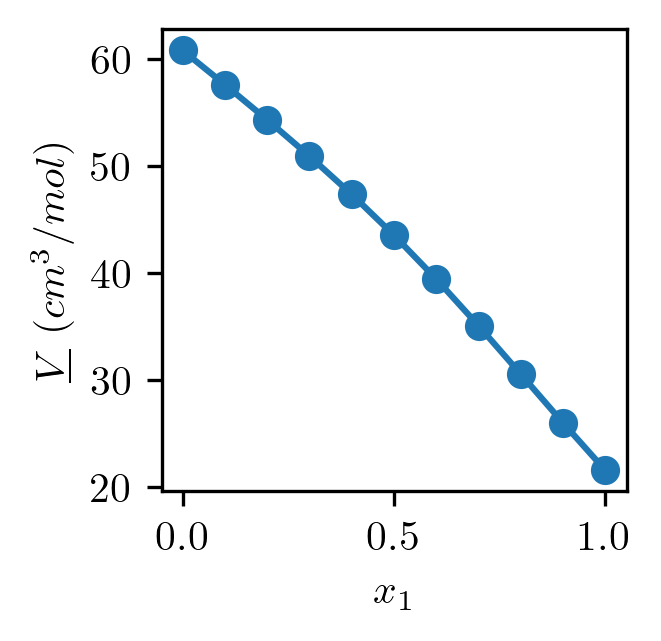

In [3]:
plt.figure(dpi=300,figsize=(2,2))
plt.rc('text', usetex=True)
x1_=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.70,0.80,0.90,1]
V_=[]
for x1 in x1_:
    
    roots=np.roots(Zcoeff(T,P,amix(x1),bmix(x1)))
    V_.append(np.min(np.real(roots[np.isreal(roots) & (np.real(roots) > 0)])) * R * 298 / 1e5)
    
plt.plot(x1_,np.asarray(V_)*10**6,marker='o')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$\underline{V}$ $(cm^3/mol)$')
plt.show()


In [6]:
MW1=18 #g/mol
MW2=46.07 #g/mol

x1_exp=np.asarray([0,0.1162,0.2221,0.2841,0.3729,0.4186,0.5266,0.6119,0.7220,0.8509,0.9489,1.0])
rho_exp=np.asarray([786.846,806.655,825.959,837.504,855.031,864.245,887.222,905.376,929.537,957.522,981.906,997.047]) #kg/m^3
rho_mod=[]
for x1 in x1_exp:
    
    x2 = 1-x1
    MW = x1*MW1+x2*MW2
    roots = np.roots(Zcoeff(T,P,amix(x1),bmix(x1)))
    V = np.min(np.real(roots[np.isreal(roots) & (np.real(roots) > 0)])) * R * 298 / 1e5
    rho_mod.append(MW/V/10**6)
    

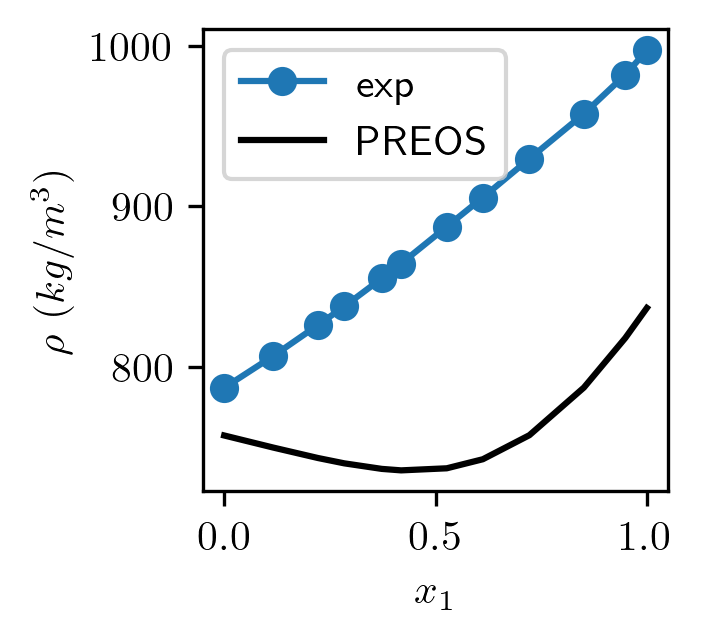

In [7]:
plt.figure(figsize=(2,2), dpi = 300)
plt.plot(x1_exp, rho_exp, marker='o', label = 'exp')
plt.plot(x1_exp, np.asarray(rho_mod)*1000,'-k', label = 'PREOS')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$\rho$ $(kg/m^3)$')
plt.legend()
plt.show()
  

## Now Let's do the same for n-Hexane and and n-decane 


| Compound | Formula | MW (g/mol) | Tc (K) | Pc (MPa) | Acentric Factor (ω) |
|----------|---------|------------|--------|----------|----------------------|
| **n‑Hexane** | C₆H₁₄ | 86.178 | 507.6 | 3.03 | 0.301 |
| **n‑Decane** | C₁₀H₂₂ | 142.286 | 617.7 | 2.11 | 0.488 |



3.8086546820691596 10.029650127827047
10.835990162376238 18.935848191469194


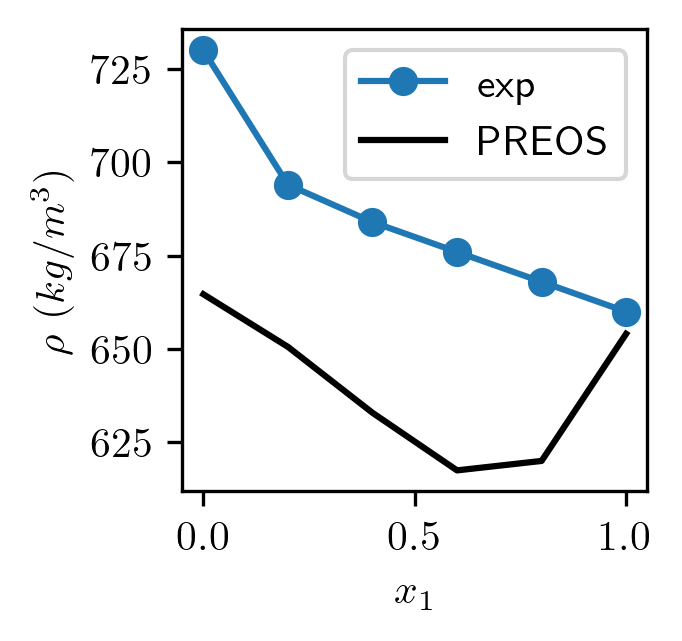

In [8]:
T=298 #K
P=101325 #Pa

##hexane
Tc1=507.6 #K
Pc1=30.3 #bar
w1=0.301

##decane
Tc2 = 617.7 #Tc
Pc2 = 21.1 #bar
w2 = 0.488

R = 8.314##j/mol*k
kij = 0

a1 = a(T,Tc1,Pc1*10**5,w1)
a2 = a(T,Tc2,Pc2*10**5,w2)
b1 = b(Tc1,Pc1*10**5)
b2 = b(Tc2,Pc2*10**5)

print(a1,a2)
print(b1*10**5,b2*10**5)

x1=np.linspace(0,1)
amix_=amix(x1)
bmix_=bmix(x1)

MW1 = 86.178 #g/mol

MW2 = 142.286 #g/mol
# Mole fraction of hexane (x_hexane)
x1_exp = np.array([1.0, 0.8, 0.6, 0.4, 0.2, 0.0])

# Experimental-density-inspired values at 298 K (g/mL)
# Representative of Tripathi (2005) and Regueira et al. (2015)
rho_exp = np.array([0.660, 0.668, 0.676, 0.684, 0.694, 0.730])*1000 #kg/m^3
rho_mod=[]

for x1 in x1_exp:
    
    x2 = 1 - x1
    MW = x1*MW1 + x2*MW2
    roots = np.roots(Zcoeff(T, P, amix(x1), bmix(x1)))
    V = np.min(np.real(roots[np.isreal(roots) & (np.real(roots) > 0)])) * R * 298 / 1e5
    rho_mod.append(MW/V/10**6)
plt.figure(figsize=(2,2), dpi = 300)
plt.plot(x1_exp, rho_exp, marker='o', label = 'exp')
plt.plot(x1_exp, np.asarray(rho_mod)*1000,'-k', label = 'PREOS')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$\rho$ $(kg/m^3)$')
plt.legend()
plt.show()
  


## Why the Peng–Robinson EOS Performs Better for Alkanes Than for Polar Solvents

The Peng–Robinson equation of state was originally developed and parameterized for **nonpolar and mildly polar hydrocarbons**, and its mathematical structure reflects that heritage. Alkanes like hexane and decane interact primarily through **London dispersion forces**, which are smooth, isotropic, and well‑approximated by the simple attractive term in PR:

$$
a(T) \propto \alpha(T_r,\omega)
$$

Because these interactions vary predictably with temperature and molecular size, the PR functional form captures their behavior with impressive accuracy. The acentric factor $\omega$ provides just enough flexibility to tune the temperature dependence of attraction without introducing strong directional effects.

Polar solvents behave very differently. Water and ethanol exhibit:

- **Strong, highly directional hydrogen bonding**
- **Large dipole moments**
- **Associative clustering in the liquid phase**
- **Abrupt structural changes with temperature**

These effects are **not** represented in the PR EOS. The attractive term assumes a **spherically symmetric**, van der Waals‑like interaction, which cannot reproduce the steep density–temperature behavior, anomalous compressibility, or strong non‑ideal mixing seen in polar fluids. As a result, PR systematically underpredicts liquid densities, misrepresents vapor pressures, and struggles with phase equilibria for associating solvents.

In short, **PR works beautifully for alkanes because their intermolecular physics matches the assumptions built into the model**, while **polar solvents violate those assumptions in fundamental ways**. This is why extensions like **CPA‑EOS**, **SAFT**, or **PR‑CPA** are preferred for hydrogen‑bonding systems, whereas PR remains a workhorse for hydrocarbon thermodynamics.



In [11]:
import teqp
import numpy as np
import pandas
import matplotlib.pyplot as plt

teqp.__version__

ModuleNotFoundError: No module named 'teqp'

In [ ]:
pip install 